# FCC ↔ BCC Solid–Solid Transition in Iron

Iron undergoes a structural phase transition from BCC (α-Fe) to FCC (γ-Fe) at
approximately 1185 K.  Despite BCC iron having a lower potential energy at 0 K, the
softer phonon spectrum of FCC produces higher vibrational entropy at elevated
temperatures, eventually stabilising the FCC structure.

This notebook builds a Debye-model phonon density of states for each structure and
compares the resulting Helmholtz free energies to recover the transition temperature.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.constants import k, eV

from ase.thermochemistry import CrystalThermo

from landau.phases.asewrapper import AsePhase
from landau.calculate import calc_phase_diagram
from landau.plot import plot_1d_T_phase_diagram

kB = k / eV  # eV / K


## 1  Debye Model

The Debye model approximates the phonon density of states as

$$g(E) = \frac{3}{E_D^3}\,E^2 \quad \text{for } 0 \le E \le E_D, \qquad E_D = k_B\,\theta_D$$

normalised so that $\int_0^{E_D} g(E)\,dE = 3$ (three modes per atom).

| Phase | Structure | $\theta_D$ (K) | $E_D$ (meV) |
|-------|-----------|--------------|-------------|
| α-Fe  | BCC       | 470           | 40.5        |
| γ-Fe  | FCC       | 390           | 33.6        |

FCC has a lower Debye temperature (softer phonons), giving higher vibrational entropy at elevated
temperatures and hence a lower free energy above the transition.

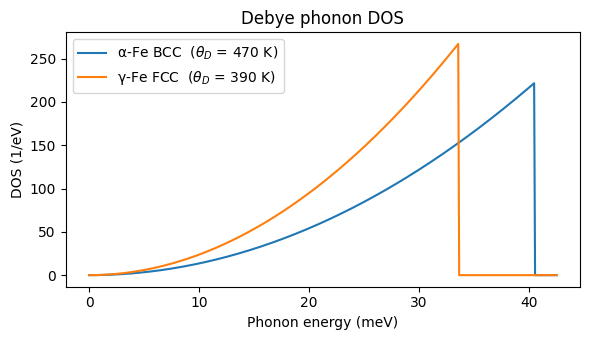

In [2]:
theta_bcc = 470.0  # K, alpha-Fe (BCC)
theta_fcc = 390.0  # K, gamma-Fe (FCC)

E_D_bcc = kB * theta_bcc
E_D_fcc = kB * theta_fcc

energies_debye = np.linspace(0.0, max(E_D_bcc, E_D_fcc) * 1.05, 500)


def debye_dos(energies, E_D):
    dos = np.where(energies <= E_D, energies**2, 0.0)
    return dos * 3.0 / trapezoid(dos, energies)


dos_bcc_debye = debye_dos(energies_debye, E_D_bcc)
dos_fcc_debye = debye_dos(energies_debye, E_D_fcc)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(energies_debye * 1e3, dos_bcc_debye, label=rf'α-Fe BCC  ($\theta_D$ = {theta_bcc:.0f} K)')
ax.plot(energies_debye * 1e3, dos_fcc_debye, label=rf'γ-Fe FCC  ($\theta_D$ = {theta_fcc:.0f} K)')
ax.set_xlabel('Phonon energy (meV)')
ax.set_ylabel('DOS (1/eV)')
ax.legend()
ax.set_title('Debye phonon DOS')
plt.tight_layout()

### Phase objects — Debye model

Each phase is wrapped in an `AsePhase` that calls `CrystalThermo` to evaluate the Helmholtz free energy

$$F(T) = E_0 + E_\text{ZPE} + k_BT\int_0^\infty g(E)\,\ln\!\left[2\sinh\!\left(\frac{E}{2k_BT}\right)\right]dE$$

The potential energies $E_0$ are representative DFT values for Fe:
BCC is taken as the reference ($E_0^\text{BCC} = 0$) and FCC lies ~57 meV/atom higher at 0 K.

In [3]:
E0_bcc = 0.000  # eV/atom, DFT reference
E0_fcc = 0.057  # eV/atom, FCC less stable at T = 0

bcc_debye = AsePhase(
    name='α-Fe (Debye)',
    fixed_concentration=0.0,
    thermochem=CrystalThermo(
        phonon_DOS=dos_bcc_debye,
        phonon_energies=energies_debye,
        formula_units=1,
        potentialenergy=E0_bcc,
    ),
)

fcc_debye = AsePhase(
    name='γ-Fe (Debye)',
    fixed_concentration=0.0,
    thermochem=CrystalThermo(
        phonon_DOS=dos_fcc_debye,
        phonon_energies=energies_debye,
        formula_units=1,
        potentialenergy=E0_fcc,
    ),
)

## 2  Helmholtz Free Energy

At $\Delta\mu = 0$ the semi-grand-canonical potential reduces to the Helmholtz free energy $F(T)$.
We compute the phase diagram for both Debye phases and use `plot_1d_T_phase_diagram` to visualise the
competing free energies.  The stable phase (lowest $F$ at each $T$) is shown with a solid line;
the metastable phase with a dashed line.


Text(0.5, 1.0, 'Helmholtz free energies — Debye model')

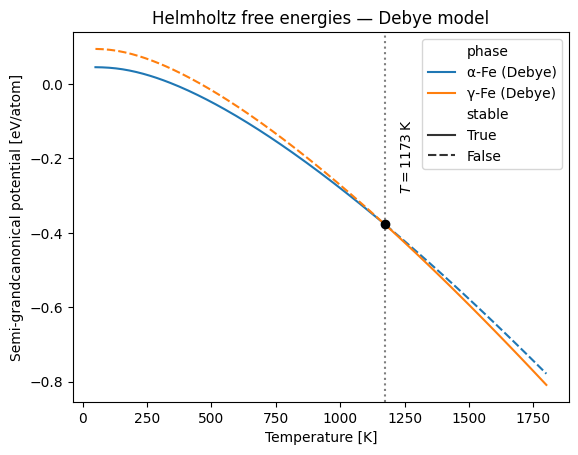

In [4]:
T = np.linspace(50, 1800, 200)

df = calc_phase_diagram(
    [bcc_debye, fcc_debye],
    Ts=T,
    mu=0.0,
    keep_unstable=True,
)

plot_1d_T_phase_diagram(df)
plt.title('Helmholtz free energies — Debye model')


## 3  Transition Temperature

The equilibrium BCC → FCC transition occurs where the Debye free energies are equal.
`calc_phase_diagram` refines the transition to high precision and marks the corresponding rows with
`border == True`.


In [5]:
df_debye = calc_phase_diagram([bcc_debye, fcc_debye], Ts=T, mu=0.0)
border = df_debye.query('border')

if not border.empty:
    T_trans = border['T'].iloc[0]
    print(f'BCC → FCC transition temperature (Debye): {T_trans:.0f} K  ({T_trans - 273.15:.0f} °C)')
    print(f'Experimental value:                        1185 K  (912 °C)')

BCC → FCC transition temperature (Debye): 1173 K  (900 °C)
Experimental value:                        1185 K  (912 °C)


## Summary

| Quantity | Debye model | Experiment |
|----------|:-----------:|:----------:|
| $T_c$ (BCC → FCC) | ~1173 K | 1185 K |

The simple Debye model reproduces the BCC → FCC transition to within ~1% despite
ignoring magnetism and anharmonicity.
